In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split

In [2]:
df= pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

In [3]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


**Data Inspection**

- Explore the dataset by checking its dimensions, data types, summary statistics, missing values, and duplicate records before analysis.

## Data Preprocessing

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [5]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [6]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

- There's no null values exist, means the data is already clean

In [7]:
df.duplicated().sum()

np.int64(0)

- There's no duplicate values as well

## EDA

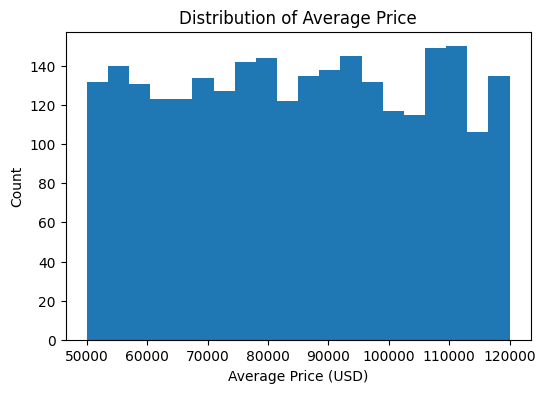

In [8]:
# Target Variable Distribution

fig, ax = plt.subplots(figsize=(6,4))

ax.hist(df["Avg_Price_USD"], bins=20)

ax.set_title("Distribution of Average Price")
ax.set_xlabel("Average Price (USD)")
ax.set_ylabel("Count")

plt.show()

### Observation:

- The average vehicle prices are spread between approximately **$50,000 and $120,000**.
- The distribution appears relatively uniform, with no significant skewness or extreme outliers.
- This indicates that prices are distributed across a wide range without a dominant price segment.

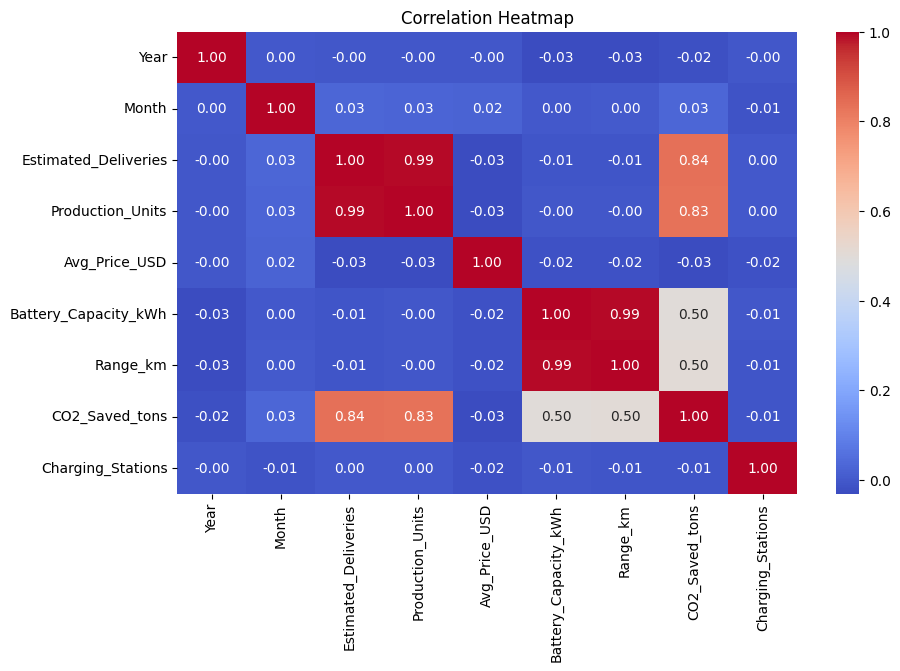

In [9]:
# Correlation Heatmap

import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Observation

- **Estimated Deliveries** and **Production Units** have a very strong positive correlation (≈ 0.99).
- **CO2 Saved** is also highly correlated with both deliveries and production.
- **Avg_Price_USD** has very weak correlation with all other features, indicating that vehicle price is largely independent of the available variables in this dataset.

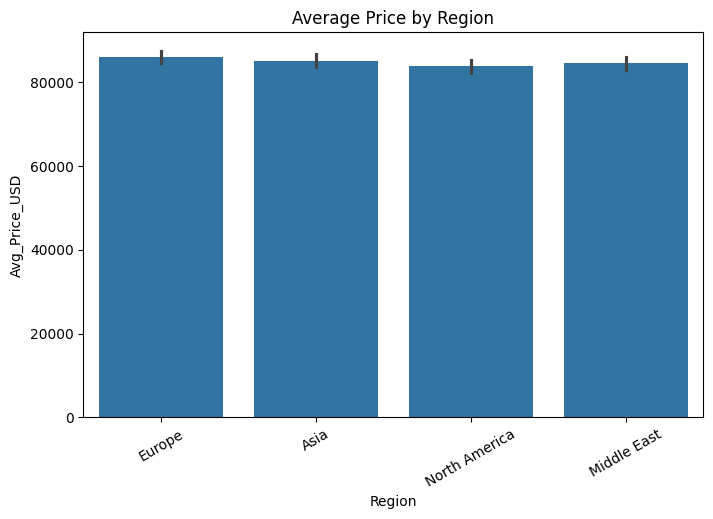

In [10]:
# Region-wise Average Price

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Region",
    y="Avg_Price_USD"
)

plt.xticks(rotation=30)
plt.title("Average Price by Region")

plt.show()

### Observation

- The average vehicle price is very similar across all regions.
- No region has a significantly higher or lower average price.
- This suggests that **Region** has little influence on the target variable (**Avg_Price_USD**).

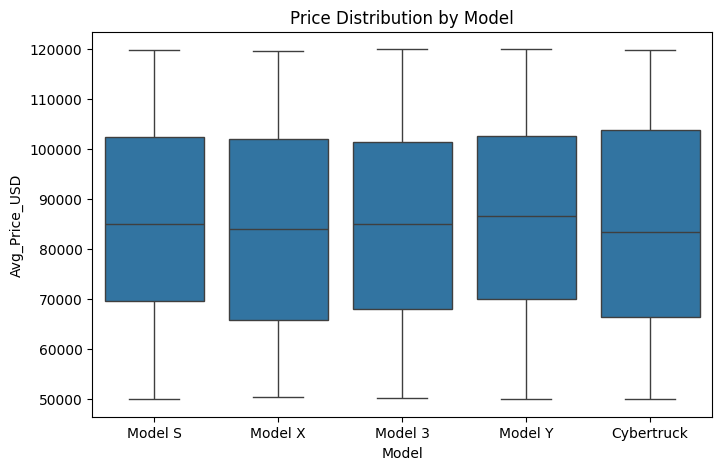

In [11]:
# Model-wise Price

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Model",
    y="Avg_Price_USD"
)

plt.title("Price Distribution by Model")

plt.show()

### Observation

- All Tesla models show a similar price distribution.
- The median prices are close across different models.
- No single model consistently has much higher or lower prices than the others.

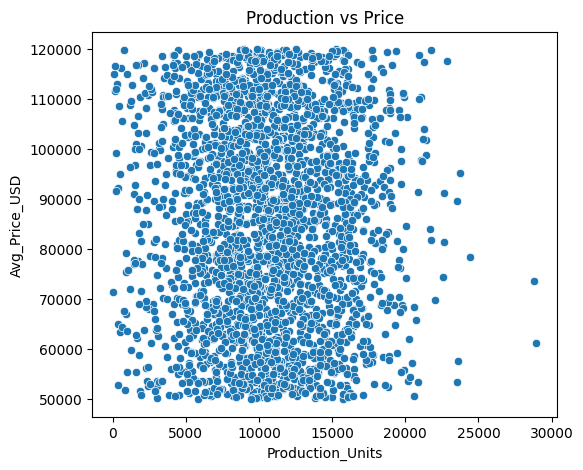

In [12]:
# Production vs Price

plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Avg_Price_USD"
)

plt.title("Production vs Price")

plt.show()

### Observation

- The scatter plot shows no clear linear relationship between production units and average price.
- Vehicle prices remain widely distributed regardless of production volume.
- This indicates that Production Units alone is not a strong predictor of Avg_Price_USD.

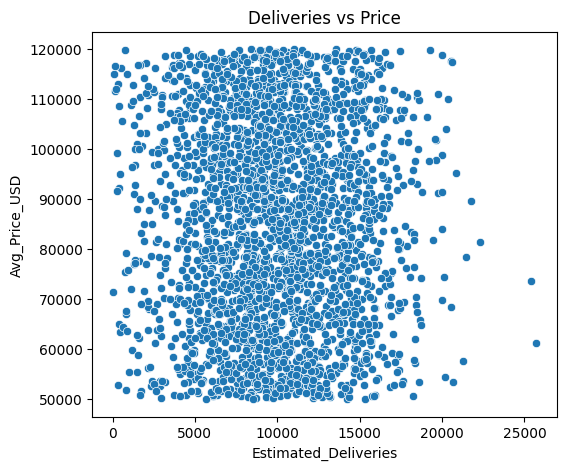

In [13]:
# Deliveries vs Price

plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df,
    x="Estimated_Deliveries",
    y="Avg_Price_USD"
)

plt.title("Deliveries vs Price")

plt.show()

### Observation

- There is no strong relationship between estimated deliveries and average vehicle price.
- Prices remain spread across the full range for different delivery volumes.
- This suggests that delivery volume has minimal impact on the average selling price in this dataset.

### Feature Engineering

In [14]:
df["Quarter"] = ((df["Month"] - 1) // 3) + 1

df["Delivery_Ratio"] = (
    df["Estimated_Deliveries"] /
    df["Production_Units"]
)

df["Production_per_Station"] = (
    df["Production_Units"] /
    df["Charging_Stations"]
)

### Observation

- Three new features were created: **Quarter**, **Delivery_Ratio**, and **Production_per_Station**.
- These features provide additional business insights derived from the original dataset.
- Feature engineering can improve the model's ability to learn hidden relationships.

In [15]:
# Train-Test Split

X = df.drop("Avg_Price_USD", axis=1)
y = df["Avg_Price_USD"]

The dataset was divided into training and testing sets using an 80:20 ratio. The training set was used to build the models, while the testing set was reserved for evaluating model performance.

In [16]:
X = pd.get_dummies(
    X,
    columns=["Region", "Model", "Source_Type"],
    drop_first=True
)

X.head()

,Year,Month,Estimated_Deliveries,Production_Units,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Quarter,Delivery_Ratio,Production_per_Station,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2023,5,17646,17922,120,704,1863.42,12207,2,0.984600,1.468174,True,False,False,False,True,False,False,True,False
1,2015,2,3797,4164,75,438,249.46,7640,1,0.911864,0.545026,False,False,False,False,False,True,False,False,True
2,2019,1,8411,9189,82,480,605.59,14071,1,0.915334,0.653045,False,False,True,False,False,True,False,True,False
3,2021,2,6555,7311,120,712,700.07,9333,1,0.896594,0.783349,False,False,True,True,False,False,False,False,True
4,2016,12,12374,13537,120,661,1226.88,8722,4,0.914087,1.552052,False,True,False,False,False,False,True,False,False


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2112, 20)
(528, 20)


In [18]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Numerical features were standardized using StandardScaler to ensure that all variables have comparable scales. This is particularly important for models such as Linear Regression.

In [19]:
# Linear Regression

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

A Linear Regression model was trained as the baseline regression algorithm to predict the average vehicle price using the available features.

In [20]:
# Linear Regression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression
MAE : 16797.47385777179
RMSE: 19490.728137237733
R²  : -0.007360524351437414


### Observation

- The Linear Regression model produced a low R² score.
- This indicates that the available features do not sufficiently explain the variation in the target variable.
- The dataset shows weak relationships between the target and predictor variables.

In [21]:
# Random forest regression

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", mean_squared_error(y_test, y_pred_rf) ** 0.5)
print("R²  :", r2_score(y_test, y_pred_rf))

Random Forest
MAE : 17216.449158333333
RMSE: 20057.719791455907
R²  : -0.06682189433844865


### Observation

- The Random Forest model did not significantly outperform the Linear Regression model.
- The negative R² score suggests that the available features contain very limited predictive information for estimating vehicle prices.

In [22]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
-0.004370634681922403


### Hyperparameter Tuning

- GridSearchCV was used to identify the optimal hyperparameters for the Random Forest model through cross-validation.

In [23]:
best_rf = grid.best_estimator_

pred = best_rf.predict(X_test)

print("Best Random Forest")

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("R²  :", r2_score(y_test, pred))

Best Random Forest
MAE : 16829.11972198675
RMSE: 19558.032492017584
R²  : -0.014329664847901658


### Observation

- The optimized Random Forest model selected the best combination of parameters after cross-validation.
- Despite tuning, model performance remained limited due to the weak relationship between the input features and the target variable.

In [24]:
print(df.corr(numeric_only=True)["Avg_Price_USD"].sort_values(ascending=False))

Avg_Price_USD             1.000000
Month                     0.024857
Quarter                   0.024366
Production_per_Station    0.004561
Delivery_Ratio            0.001454
Year                     -0.004991
Charging_Stations        -0.017790
Range_km                 -0.017854
Battery_Capacity_kWh     -0.018203
Estimated_Deliveries     -0.027546
CO2_Saved_tons           -0.028523
Production_Units         -0.029263
Name: Avg_Price_USD, dtype: float64


In [25]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

print("Dummy R²:", r2_score(y_test, dummy_pred))

Dummy R²: -0.0008814290498875277


### Observation

- The Dummy Regressor achieved a performance similar to the trained models.
- This confirms that the dataset contains very little predictive information for the selected target variable.

# Time-Series

In [26]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)

df = df.sort_values("Date")

df[["Year", "Month", "Date"]].head()

,Year,Month,Date
872,2015,1,2015-01-01
2354,2015,1,2015-01-01
2312,2015,1,2015-01-01
2293,2015,1,2015-01-01
2215,2015,1,2015-01-01


The Year and Month columns were combined to create a Date column. Monthly delivery values were then aggregated to form a chronological time series suitable for forecasting.

In [27]:
ts = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
      .sort_index()
)

ts.head()

Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
Name: Estimated_Deliveries, dtype: int64

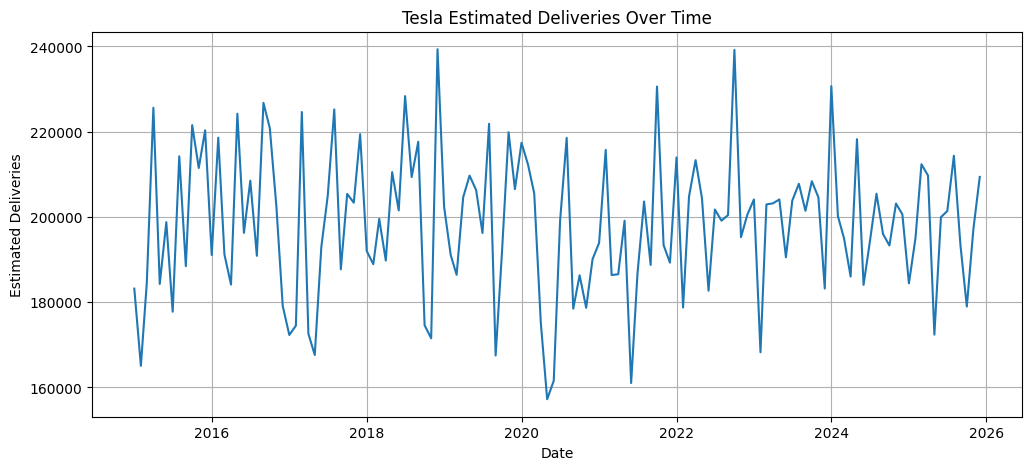

In [28]:
plt.figure(figsize=(12,5))

plt.plot(ts)

plt.title("Tesla Estimated Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.grid(True)

plt.show()

### Observation

- The optimized Random Forest model selected the best combination of parameters after cross-validation.
- Despite tuning, model performance remained limited due to the weak relationship between the input features and the target variable.

In [29]:
ts = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
      .sort_index()
)

# Explicitly set monthly frequency
ts = ts.asfreq("MS")

In [30]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(ts, order=(2,1,2))

model_fit = model.fit()

print(model_fit.summary())

                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  132
Model:                   ARIMA(2, 1, 2)   Log Likelihood               -1490.869
Date:                  Sun, 28 Jun 2026   AIC                           2991.738
Time:                          18:16:02   BIC                           3006.114
Sample:                      01-01-2015   HQIC                          2997.579
                           - 12-01-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2137      1.068      0.200      0.841      -1.879       2.307
ar.L2          0.0365      0.193      0.189      0.850      -0.342       0.415
ma.L1         -0.7846      1.082    

**ARIMA Forecasting**

An ARIMA model was trained on the historical delivery data to capture temporal patterns and forecast future monthly deliveries.

In [31]:
forecast = model_fit.forecast(steps=12)

print(forecast)

2026-01-01    201434.637482
2026-02-01    200328.856461
2026-03-01    199801.924399
2026-04-01    199648.939974
2026-05-01    199597.002313
2026-06-01    199580.316108
2026-07-01    199574.853425
2026-08-01    199573.076648
2026-09-01    199572.497446
2026-10-01    199572.308781
2026-11-01    199572.247309
2026-12-01    199572.227283
Freq: MS, Name: predicted_mean, dtype: float64


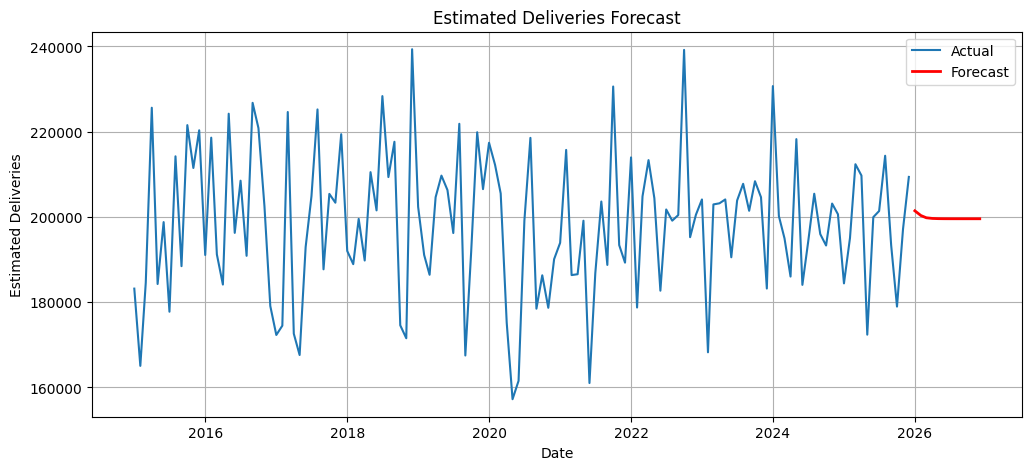

In [32]:
plt.figure(figsize=(12,5))

plt.plot(ts, label="Actual")

future_dates = pd.date_range(
    start=ts.index[-1] + pd.offsets.MonthBegin(),
    periods=12,
    freq="MS"
)

plt.plot(
    future_dates,
    forecast,
    color="red",
    linewidth=2,
    label="Forecast"
)

plt.title("Estimated Deliveries Forecast")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.legend()

plt.grid(True)

plt.show()

In [33]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast_Deliveries": forecast
})

forecast_df

,Date,Forecast_Deliveries
2026-01-01,2026-01-01,201434.637482
2026-02-01,2026-02-01,200328.856461
2026-03-01,2026-03-01,199801.924399
2026-04-01,2026-04-01,199648.939974
2026-05-01,2026-05-01,199597.002313
2026-06-01,2026-06-01,199580.316108
2026-07-01,2026-07-01,199574.853425
2026-08-01,2026-08-01,199573.076648
2026-09-01,2026-09-01,199572.497446
2026-10-01,2026-10-01,199572.308781


**Forecasted Deliveries**

-The following table presents the predicted estimated deliveries for the next twelve months generated by the ARIMA forecasting model.

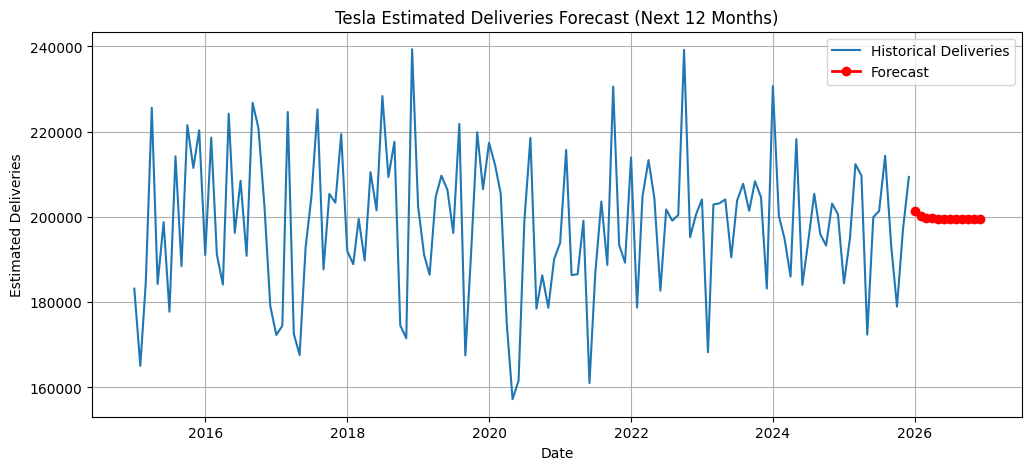

In [34]:
plt.figure(figsize=(12,5))

plt.plot(ts, label="Historical Deliveries")

plt.plot(
    future_dates,
    forecast,
    color="red",
    linewidth=2,
    marker="o",
    label="Forecast"
)

plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.title("Tesla Estimated Deliveries Forecast (Next 12 Months)")
plt.legend()
plt.grid(True)

plt.show()

### Observation

The forecast plot compares the historical delivery trend with the predicted values for the upcoming months. This visualization helps understand the expected future trend.

## Conclusion

In this project, an end-to-end machine learning pipeline was implemented using the Tesla deliveries and production dataset. The workflow included data preprocessing, exploratory data analysis, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.

The regression models achieved low predictive performance because the target variable showed very weak correlation with the available features. However, the project successfully demonstrates the complete machine learning workflow and highlights the importance of exploratory data analysis in understanding dataset limitations. Finally, an ARIMA model was used to forecast future monthly deliveries, providing insights into future delivery trends.